# Synthetic Truth Recovery

Validate method calibration by generating synthetic observed data at a **known** parameter vector,
then re-running regression adjustment and synthetic likelihood MCMC, and checking whether the
true values fall within the 90% credible intervals.

**True parameters:** $\theta_\text{true} = (\beta, \gamma, \rho) = (0.17, 0.086, 0.31)$
(the SMC-ABC balanced posterior mean, rounded to 3 d.p.)

If the regression-adjusted or synthetic likelihood posteriors are well-calibrated, the 90% CI
should cover $\theta_\text{true}$ for all three parameters.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "scripts"))
from simulator import simulate_batch

# ── Load prior pool ──────────────────────────────────────────────────────────
raw     = np.load(ROOT / "data" / "prior_simulations.npz")
thetas  = raw["thetas"]                            # (M, 3)
sim_inf = raw["infected_fractions"]                # (M, R, 201)
sim_rew = raw["rewire_counts"].astype(float)       # (M, R, 201)
sim_deg = raw["degree_histograms"].astype(float)   # (M, R, 31)
M, R    = sim_inf.shape[:2]

PRIOR_LOW  = np.array([0.05, 0.02, 0.0])
PRIOR_HIGH = np.array([0.50, 0.20, 0.8])
PARAM_NAMES = [r"$\beta$", r"$\gamma$", r"$\rho$"]
print(f"Prior pool: {M:,} draws × {R} replicates")

Prior pool: 10,000 draws × 40 replicates


In [2]:
# ── Summary statistics (copied from regression_adjustment.ipynb) ─────────────
DEGREES = np.arange(31, dtype=float)

def _degree_mean(deg):
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    return ((deg * DEGREES).sum(axis=2, keepdims=True) / total).mean(axis=1)

def _degree_std(deg):
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    mu  = (deg * DEGREES).sum(axis=2) / total.squeeze(2)
    mu2 = (deg * DEGREES**2).sum(axis=2) / total.squeeze(2)
    return np.sqrt((mu2 - mu**2).clip(min=0)).mean(axis=1, keepdims=True)

def _degree_entropy(deg):
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    p = deg / total
    return -(p * np.log(p + 1e-10)).sum(axis=2).mean(axis=1, keepdims=True)

def _degree_quantile(deg, q):
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    cdf = np.cumsum(deg / total, axis=2)
    return (cdf < q).sum(axis=2).astype(float).mean(axis=1, keepdims=True)

FEATURE_FUNCS = {
    "peak_inf":          lambda i, w, d: np.max(i, axis=2).mean(axis=1, keepdims=True),
    "time_to_peak_inf":  lambda i, w, d: np.argmax(i, axis=2).astype(float).mean(axis=1, keepdims=True),
    "final_inf":         lambda i, w, d: i[:, :, -1].mean(axis=1, keepdims=True),
    "total_inf":         lambda i, w, d: i.sum(axis=2).mean(axis=1, keepdims=True),
    "epidemic_duration": lambda i, w, d: (i > 0.01).sum(axis=2).astype(float).mean(axis=1, keepdims=True),
    "std_peak_inf":      lambda i, w, d: np.max(i, axis=2).std(axis=1, keepdims=True),
    "std_total_inf":     lambda i, w, d: i.sum(axis=2).std(axis=1, keepdims=True),
    "total_rew":         lambda i, w, d: w.sum(axis=2).mean(axis=1, keepdims=True),
    "peak_rew":          lambda i, w, d: np.max(w, axis=2).mean(axis=1, keepdims=True),
    "time_to_peak_rew":  lambda i, w, d: np.argmax(w, axis=2).astype(float).mean(axis=1, keepdims=True),
    "std_total_rew":     lambda i, w, d: w.sum(axis=2).std(axis=1, keepdims=True),
    "std_peak_rew":      lambda i, w, d: np.max(w, axis=2).std(axis=1, keepdims=True),
    "mean_degree":       lambda i, w, d: _degree_mean(d),
    "std_degree":        lambda i, w, d: _degree_std(d),
    "degree_entropy":    lambda i, w, d: _degree_entropy(d),
    "degree_q25":        lambda i, w, d: _degree_quantile(d, 0.25),
    "degree_q50":        lambda i, w, d: _degree_quantile(d, 0.50),
    "degree_q75":        lambda i, w, d: _degree_quantile(d, 0.75),
    "isolated_frac":     lambda i, w, d: (d[:, :, 0] / d.sum(axis=2).clip(min=1)).mean(axis=1, keepdims=True),
    "high_degree_frac":  lambda i, w, d: (d[:, :, 20:].sum(axis=2) / d.sum(axis=2).clip(min=1)).mean(axis=1, keepdims=True),
}

BALANCED_FEATURES = [
    "peak_inf", "epidemic_duration", "total_inf", "std_peak_inf", "std_total_inf",
    "total_rew", "peak_rew", "std_total_rew", "std_peak_rew",
    "mean_degree", "std_degree", "degree_entropy",
    "degree_q25", "degree_q50", "degree_q75",
]

def compute_summaries(inf, rew, deg):
    squeeze = inf.ndim == 2
    if squeeze:
        inf, rew, deg = inf[np.newaxis], rew[np.newaxis], deg[np.newaxis]
    rew, deg = rew.astype(float), deg.astype(float)
    parts = []
    for name in BALANCED_FEATURES:
        feat = FEATURE_FUNCS[name](inf, rew, deg)
        parts.append(feat[:, np.newaxis] if feat.ndim == 1 else feat)
    result = np.concatenate(parts, axis=1)
    return result[0] if squeeze else result

# Pre-compute prior pool summaries (used by regression adjustment)
sim_stats = compute_summaries(sim_inf, sim_rew, sim_deg)
print(f"Sim stats: {sim_stats.shape}")

Sim stats: (10000, 15)


In [3]:
# ── Generate synthetic observed data at known theta_true ─────────────────────
THETA_TRUE  = np.array([0.17, 0.086, 0.31])   # SMC-ABC balanced posterior mean
N_OBS_REPS  = 40
rng_syn     = np.random.default_rng(seed=12345)

results_syn = simulate_batch(THETA_TRUE[np.newaxis], n_replicates=N_OBS_REPS, rng=rng_syn)

syn_inf = np.array([results_syn[0][r][0] for r in range(N_OBS_REPS)])   # (40, 201)
syn_rew = np.array([results_syn[0][r][1] for r in range(N_OBS_REPS)])   # (40, 201)
syn_deg = np.array([results_syn[0][r][2] for r in range(N_OBS_REPS)])   # (40, 31)

obs_syn_stats = compute_summaries(syn_inf, syn_rew, syn_deg)   # (15,)
print(f"Synthetic obs stats shape: {obs_syn_stats.shape}")
print(f"True parameters: β={THETA_TRUE[0]}, γ={THETA_TRUE[1]}, ρ={THETA_TRUE[2]}")

Synthetic obs stats shape: (15,)
True parameters: β=0.17, γ=0.086, ρ=0.31


In [4]:
# ── Regression adjustment on synthetic data ──────────────────────────────────
# Reuses prior pool — zero additional simulator calls.

ABC_QUANTILE = 0.05

scaler    = StandardScaler()
sim_sc    = scaler.fit_transform(sim_stats)           # (M, F)
obs_sc    = scaler.transform(obs_syn_stats[None])[0]  # (F,)

delta     = sim_sc - obs_sc
dists     = np.linalg.norm(delta, axis=1)
h         = np.quantile(dists, ABC_QUANTILE)
mask      = dists <= h

theta_acc = thetas[mask]
delta_acc = delta[mask]
dists_acc = dists[mask]

u       = dists_acc / h
weights = (3/4) * (1 - u**2)
weights = weights / weights.sum()
sw      = np.sqrt(weights)

X  = np.column_stack([np.ones(len(delta_acc)), delta_acc]) * sw[:, None]
Yw = theta_acc * sw[:, None]
coefs, _, _, _ = np.linalg.lstsq(X, Yw, rcond=None)

theta_adj_syn = theta_acc - delta_acc @ coefs[1:]

print(f"Accepted {mask.sum()} / {M} draws (q={ABC_QUANTILE:.0%}), h={h:.4f}")
print(f"Adjusted sample shape: {theta_adj_syn.shape}")

Accepted 500 / 10000 draws (q=5%), h=1.4959
Adjusted sample shape: (500, 3)


In [5]:
# ── Regression adjustment coverage check ─────────────────────────────────────
print("Regression Adjustment — 90% CI coverage")
print(f"{'Param':8s} {'True':>8} {'Mean':>8} {'5%':>8} {'95%':>8} {'Covered?':>10}")
print("-" * 52)
ra_covered = []
for j, name in enumerate(["β", "γ", "ρ"]):
    q05 = np.quantile(theta_adj_syn[:, j], 0.05)
    q95 = np.quantile(theta_adj_syn[:, j], 0.95)
    mean = theta_adj_syn[:, j].mean()
    covered = q05 <= THETA_TRUE[j] <= q95
    ra_covered.append(covered)
    print(f"{name:8s} {THETA_TRUE[j]:>8.4f} {mean:>8.4f} {q05:>8.4f} {q95:>8.4f} {'YES' if covered else 'NO':>10}")

Regression Adjustment — 90% CI coverage
Param        True     Mean       5%      95%   Covered?
----------------------------------------------------
β          0.1700   0.1773   0.1448   0.2309        YES
γ          0.0860   0.0860   0.0762   0.0979        YES
ρ          0.3100   0.3140   0.3032   0.3273        YES


## SBC for Regression Adjustment (N = 100)

Single-point recovery checks one interior value; **Simulation-Based Calibration** (SBC)
draws $N=100$ parameter vectors $\theta^\ast$ uniformly from the prior, generates synthetic
data at each, runs regression adjustment, and checks whether $\theta^\ast$ falls inside
the posterior credible interval.  For a perfectly calibrated method the empirical coverage
at nominal level $\alpha$ should equal $\alpha$ for every parameter.

Regression adjustment reuses the existing prior pool for every repetition, so no additional
prior simulations are needed — only $100 \times 40 = 4\,000$ new simulator calls
(one fresh data set per $\theta^\ast$).

Synthetic likelihood is **not** repeated over the grid: a single SL MCMC run already
costs ${\sim}2\,000\times 150\times 40 = 12{,}000{,}000$ simulator evaluations, making
100 repetitions computationally infeasible.

In [6]:
# ── SBC for Regression Adjustment (N=100 draws from prior) ───────────────────
N_SBC        = 100
N_OBS_REPS_SBC = N_OBS_REPS   # reuse same 40 replicates per synthetic dataset
NOMINAL_LEVELS = np.array([0.50, 0.80, 0.90, 0.95])

rng_sbc = np.random.default_rng(seed=7)

# Draw N_SBC parameter vectors uniformly from the prior
sbc_thetas = rng_sbc.uniform(PRIOR_LOW, PRIOR_HIGH, size=(N_SBC, 3))

# sbc_covered[i, j, q] = True  iff  theta_i[j] falls in the (NOMINAL_LEVELS[q]) CI
sbc_covered = np.zeros((N_SBC, 3, len(NOMINAL_LEVELS)), dtype=bool)

t_sbc_start = time.perf_counter()
for i, theta_i in enumerate(sbc_thetas):
    # ── generate synthetic data at theta_i ──────────────────────────────────
    res_i   = simulate_batch(theta_i[np.newaxis], n_replicates=N_OBS_REPS_SBC, rng=rng_sbc)
    inf_i   = np.array([res_i[0][r][0] for r in range(N_OBS_REPS_SBC)])
    rew_i   = np.array([res_i[0][r][1] for r in range(N_OBS_REPS_SBC)])
    deg_i   = np.array([res_i[0][r][2] for r in range(N_OBS_REPS_SBC)])
    obs_i   = compute_summaries(inf_i, rew_i, deg_i)   # (F,)

    # ── regression adjustment (same config as above) ─────────────────────────
    obs_sc_i   = scaler.transform(obs_i[None])[0]
    delta_i    = sim_sc - obs_sc_i
    dists_i    = np.linalg.norm(delta_i, axis=1)
    h_i        = np.quantile(dists_i, ABC_QUANTILE)
    mask_i     = dists_i <= h_i

    theta_acc_i  = thetas[mask_i]
    delta_acc_i  = delta_i[mask_i]
    u_i          = dists_i[mask_i] / h_i
    weights_i    = (3/4) * (1 - u_i**2)
    weights_i   /= weights_i.sum()
    sw_i         = np.sqrt(weights_i)

    X_i  = np.column_stack([np.ones(len(delta_acc_i)), delta_acc_i]) * sw_i[:, None]
    Yw_i = theta_acc_i * sw_i[:, None]
    coefs_i, _, _, _ = np.linalg.lstsq(X_i, Yw_i, rcond=None)
    theta_adj_i = theta_acc_i - delta_acc_i @ coefs_i[1:]

    # ── coverage at each nominal level ───────────────────────────────────────
    for q_idx, q in enumerate(NOMINAL_LEVELS):
        alpha = 1 - q
        lo = np.quantile(theta_adj_i, alpha / 2, axis=0)
        hi = np.quantile(theta_adj_i, 1 - alpha / 2, axis=0)
        sbc_covered[i, :, q_idx] = (lo <= theta_i) & (theta_i <= hi)

    if (i + 1) % 25 == 0:
        elapsed = time.perf_counter() - t_sbc_start
        rem     = elapsed / (i + 1) * (N_SBC - i - 1)
        print(f"  {i+1}/{N_SBC}  elapsed={elapsed:.0f}s  ~{rem:.0f}s left")

print(f"SBC complete in {time.perf_counter()-t_sbc_start:.1f}s")

  25/100  elapsed=0s  ~1s left
  50/100  elapsed=1s  ~1s left
  75/100  elapsed=1s  ~0s left
  100/100  elapsed=2s  ~0s left
SBC complete in 1.8s


SBC Empirical Coverage — Regression Adjustment (N=100)
Param     50% CI  80% CI  90% CI  95% CI
------------------------------------------
β         59%      88%      93%      97%    
γ         57%      89%      98%      99%    
ρ         51%      90%      95%      98%    


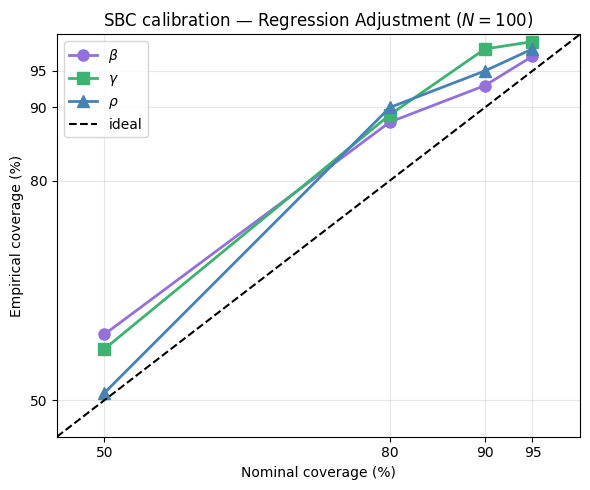

Saved figures/sbc_ra_coverage.png


In [7]:
# ── SBC coverage summary + calibration figure ────────────────────────────────
print("SBC Empirical Coverage — Regression Adjustment (N=100)")
print(f"{'Param':8s}", end="")
for q in NOMINAL_LEVELS:
    print(f"  {q:.0%} CI", end="")
print()
print("-" * 42)
for j, name in enumerate(["β", "γ", "ρ"]):
    print(f"{name:8s}", end="")
    for q_idx in range(len(NOMINAL_LEVELS)):
        emp = sbc_covered[:, j, q_idx].mean()
        print(f"  {emp:.0%}    ", end="")
    print()

# ── calibration curve ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
colors  = ["mediumpurple", "mediumseagreen", "steelblue"]
markers = ["o", "s", "^"]

for j, (name, col, mk) in enumerate(zip([r"$\beta$", r"$\gamma$", r"$\rho$"],
                                         colors, markers)):
    emp_cov = sbc_covered[:, j, :].mean(axis=0) * 100
    ax.plot(NOMINAL_LEVELS * 100, emp_cov,
            marker=mk, color=col, lw=2, ms=8, label=name)

# ideal diagonal
diag = np.array([45, 100])
ax.plot(diag, diag, "k--", lw=1.5, label="ideal")

ax.set(xlabel="Nominal coverage (%)", ylabel="Empirical coverage (%)",
       title=f"SBC calibration — Regression Adjustment ($N={N_SBC}$)",
       xlim=(45, 100), ylim=(45, 100),
       xticks=NOMINAL_LEVELS * 100, yticks=NOMINAL_LEVELS * 100)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "figures" / "sbc_ra_coverage.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/sbc_ra_coverage.png")

In [8]:
# ── Synthetic likelihood MCMC on synthetic data ───────────────────────────────
# Same config as the original SL run to validate those exact results.

N_SIM        = 150
R_SIM        = 40
N_STEPS      = 2_000
BURN_IN_SL   = 500
ADAPT_START  = 100
EPSILON_REG  = 1e-6
STEP_SIZE_INIT = np.array([0.03, 0.01, 0.01])

# Start at the regression-adjusted posterior mean (warmer start)
THETA_INIT_SL = theta_adj_syn.mean(axis=0)
print(f"SL init: β={THETA_INIT_SL[0]:.4f}, γ={THETA_INIT_SL[1]:.4f}, ρ={THETA_INIT_SL[2]:.4f}")


def simulate_summaries_sl(theta, N_sim, R_sim, rng):
    thetas_rep = np.tile(theta, (N_sim, 1))
    batch = simulate_batch(thetas_rep, n_replicates=R_sim, rng=rng)
    inf_b = np.empty((N_sim, R_sim, 201))
    rew_b = np.empty((N_sim, R_sim, 201))
    deg_b = np.empty((N_sim, R_sim, 31))
    for i in range(N_sim):
        for r in range(R_sim):
            inf_b[i, r] = batch[i][r][0]
            rew_b[i, r] = batch[i][r][1]
            deg_b[i, r] = batch[i][r][2]
    return compute_summaries(inf_b, rew_b, deg_b)   # (N_sim, p)


def log_sl(theta, s_obs, N_sim, R_sim, rng):
    stats = simulate_summaries_sl(theta, N_sim, R_sim, rng)
    mu   = stats.mean(axis=0)
    diff = s_obs - mu
    lw   = LedoitWolf().fit(stats)
    Sig  = lw.covariance_
    sign, logdet = np.linalg.slogdet(Sig)
    if sign <= 0:
        return -np.inf
    p_ = len(mu)
    quad = diff @ np.linalg.solve(Sig, diff)
    return -0.5 * (p_ * np.log(2 * np.pi) + logdet + quad)


def run_sl_mcmc(n_steps, theta_init, s_obs, N_sim, R_sim,
                step_size_init, seed=99, adapt_start=100, eps=1e-6):
    d = len(theta_init)
    sd = 2.38**2 / d
    rng = np.random.default_rng(seed)
    chain = np.empty((n_steps + 1, d))
    lls   = np.empty(n_steps + 1)
    chain[0] = theta_init
    lls[0]   = log_sl(theta_init, s_obs, N_sim, R_sim, rng)
    n_accept = 0
    prop_cov = np.diag(step_size_init**2)
    t0 = time.perf_counter()
    for step in range(1, n_steps + 1):
        theta_curr = chain[step - 1]
        if step >= adapt_start:
            past = chain[:step]
            prop_cov = sd * np.cov(past.T) + eps * np.eye(d)
        theta_prop = rng.multivariate_normal(theta_curr, prop_cov)
        if np.any(theta_prop < PRIOR_LOW) or np.any(theta_prop > PRIOR_HIGH):
            chain[step] = theta_curr
            lls[step]   = lls[step - 1]
            continue
        ll_prop   = log_sl(theta_prop, s_obs, N_sim, R_sim, rng)
        log_alpha = ll_prop - lls[step - 1]
        if np.log(rng.random()) < log_alpha:
            chain[step] = theta_prop
            lls[step]   = ll_prop
            n_accept   += 1
        else:
            chain[step] = theta_curr
            lls[step]   = lls[step - 1]
        if step % 400 == 0:
            elapsed = time.perf_counter() - t0
            rem     = elapsed / step * (n_steps - step)
            print(f"  step {step}/{n_steps}  accept={n_accept/step:.1%}  "
                  f"θ={chain[step].round(3)}  elapsed={elapsed:.0f}s  ~{rem:.0f}s left")
    print(f"Done in {time.perf_counter()-t0:.1f}s  |  accept={n_accept/n_steps:.1%}")
    return chain, lls, n_accept / n_steps


print(f"Running SL MCMC: {N_STEPS} steps × {N_SIM} sim-sets × {R_SIM} reps…")
chain_sl_syn, lls_sl_syn, acc_sl_syn = run_sl_mcmc(
    N_STEPS, THETA_INIT_SL, obs_syn_stats, N_SIM, R_SIM,
    STEP_SIZE_INIT, seed=99, adapt_start=ADAPT_START, eps=EPSILON_REG,
)
posterior_sl_syn = chain_sl_syn[BURN_IN_SL:]

# Thin to reduce autocorrelation
def autocorr(x, max_lag=200):
    x = x - x.mean()
    result = np.correlate(x, x, mode="full")[len(x)-1:]
    return result[:max_lag+1] / result[0]

THIN = 1
for j in range(3):
    ac = autocorr(posterior_sl_syn[:, j])
    below = np.where(np.abs(ac) < 0.1)[0]
    if len(below) > 0:
        THIN = max(THIN, below[0])
posterior_sl_syn_thin = posterior_sl_syn[::THIN]
print(f"Thinning interval: {THIN}  →  {len(posterior_sl_syn_thin)} thinned draws")

SL init: β=0.1773, γ=0.0860, ρ=0.3140
Running SL MCMC: 2000 steps × 150 sim-sets × 40 reps…
  step 400/2000  accept=26.0%  θ=[0.173 0.087 0.31 ]  elapsed=150s  ~598s left
  step 800/2000  accept=27.1%  θ=[0.173 0.085 0.309]  elapsed=301s  ~451s left
  step 1200/2000  accept=29.3%  θ=[0.185 0.088 0.318]  elapsed=452s  ~301s left
  step 1600/2000  accept=29.5%  θ=[0.18  0.088 0.317]  elapsed=604s  ~151s left
  step 2000/2000  accept=28.3%  θ=[0.178 0.09  0.316]  elapsed=756s  ~0s left
Done in 755.8s  |  accept=28.3%
Thinning interval: 16  →  94 thinned draws


In [9]:
# ── Synthetic likelihood coverage check ──────────────────────────────────────
print("Synthetic Likelihood — 90% CI coverage")
print(f"{'Param':8s} {'True':>8} {'Mean':>8} {'5%':>8} {'95%':>8} {'Covered?':>10}")
print("-" * 52)
sl_covered = []
for j, name in enumerate(["β", "γ", "ρ"]):
    q05 = np.quantile(posterior_sl_syn_thin[:, j], 0.05)
    q95 = np.quantile(posterior_sl_syn_thin[:, j], 0.95)
    mean = posterior_sl_syn_thin[:, j].mean()
    covered = q05 <= THETA_TRUE[j] <= q95
    sl_covered.append(covered)
    print(f"{name:8s} {THETA_TRUE[j]:>8.4f} {mean:>8.4f} {q05:>8.4f} {q95:>8.4f} {'YES' if covered else 'NO':>10}")

Synthetic Likelihood — 90% CI coverage
Param        True     Mean       5%      95%   Covered?
----------------------------------------------------
β          0.1700   0.1760   0.1698   0.1828        YES
γ          0.0860   0.0871   0.0840   0.0896        YES
ρ          0.3100   0.3126   0.3050   0.3214        YES


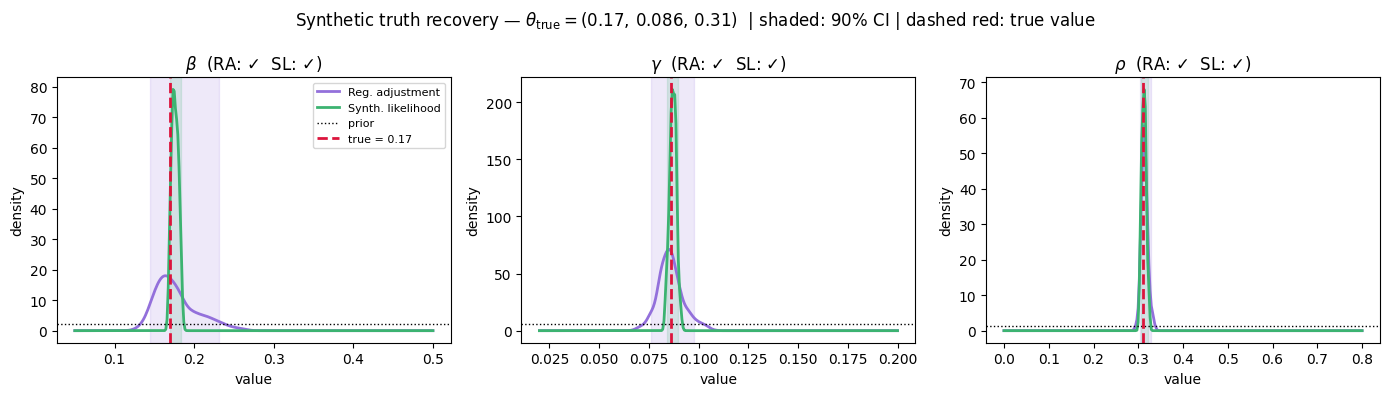

Saved figures/synthetic_truth_coverage.png


In [10]:
# ── Coverage figure ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
param_labels_plain = ["β", "γ", "ρ"]

for j, (ax, name, pname) in enumerate(zip(axes, PARAM_NAMES, param_labels_plain)):
    xmin = min(theta_adj_syn[:, j].min(), posterior_sl_syn_thin[:, j].min(),
               PRIOR_LOW[j])
    xmax = max(theta_adj_syn[:, j].max(), posterior_sl_syn_thin[:, j].max(),
               PRIOR_HIGH[j])
    xs = np.linspace(xmin, xmax, 300)

    # Regression adjustment
    kde_ra = gaussian_kde(theta_adj_syn[:, j])
    ax.plot(xs, kde_ra(xs), color="mediumpurple", lw=2, label="Reg. adjustment")
    q05_ra = np.quantile(theta_adj_syn[:, j], 0.05)
    q95_ra = np.quantile(theta_adj_syn[:, j], 0.95)
    ax.axvspan(q05_ra, q95_ra, alpha=0.15, color="mediumpurple")

    # Synthetic likelihood
    kde_sl = gaussian_kde(posterior_sl_syn_thin[:, j])
    ax.plot(xs, kde_sl(xs), color="mediumseagreen", lw=2, label="Synth. likelihood")
    q05_sl = np.quantile(posterior_sl_syn_thin[:, j], 0.05)
    q95_sl = np.quantile(posterior_sl_syn_thin[:, j], 0.95)
    ax.axvspan(q05_sl, q95_sl, alpha=0.15, color="mediumseagreen")

    # Prior
    ax.axhline(1 / (PRIOR_HIGH[j] - PRIOR_LOW[j]), color="black",
               ls=":", lw=1, label="prior")

    # True value
    ax.axvline(THETA_TRUE[j], color="crimson", lw=2, ls="--",
               label=f"true = {THETA_TRUE[j]}")

    ax.set(title=f"{name}  (RA: {'✓' if ra_covered[j] else '✗'}  SL: {'✓' if sl_covered[j] else '✗'})",
           xlabel="value", ylabel="density")
    if j == 0:
        ax.legend(fontsize=8)

plt.suptitle(r"Synthetic truth recovery — $\theta_\mathrm{true}=(0.17,\,0.086,\,0.31)$  "
             r"| shaded: 90% CI | dashed red: true value")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "synthetic_truth_coverage.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/synthetic_truth_coverage.png")

In [11]:
# ── Save results ─────────────────────────────────────────────────────────────
np.savez(
    ROOT / "data" / "synthetic_truth_results.npz",
    theta_true          = THETA_TRUE,
    theta_adj_syn       = theta_adj_syn,
    posterior_sl_syn    = posterior_sl_syn_thin,
    ra_covered          = np.array(ra_covered),
    sl_covered          = np.array(sl_covered),
    acc_sl_syn          = np.array(acc_sl_syn),
    thin_sl             = np.array(THIN),
    # SBC results
    sbc_thetas          = sbc_thetas,
    sbc_covered         = sbc_covered,
    sbc_nominal_levels  = NOMINAL_LEVELS,
)
print("Saved data/synthetic_truth_results.npz")

Saved data/synthetic_truth_results.npz
